<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airbnb Paris — pricing (case study)

**Applied AI Academy — problem set with worked answers**

**Rows:** 11,241  ·  **Source file:** `airbnb_paris.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/airbnb_paris.csv"
LOCAL = "airbnb_paris.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (11241, 19)


,PricePerGuest,#Bedrooms,#Beds,Guests,#Bathrooms,RealBed?,StrictCancellationPolicy?,CleaningFee?,HostIdentityVerified?,InstantBooking?,AvgReviewScore,#ID,CityID,DistrictID,City,District,Price per Day USD,Price per Day EUR,Avg Price per Month EUR
0,466.0,0,1,1,1.0,1,0,0,0,0,100,9943,10,1,Tokyo,Akihabara,466.0,396.566,12070.477625
1,300.0,1,1,1,1.0,1,0,0,1,0,100,10589,10,4,Tokyo,Shimbashi,300.0,255.300,7770.693750
2,280.0,1,1,1,1.0,1,0,0,1,0,93,9502,9,4,Venice,Dorsoduro,280.0,238.280,7252.647500
3,275.0,1,1,1,1.0,1,1,1,1,0,97,10517,10,3,Tokyo,Ebisu,275.0,234.025,7123.135938
4,269.0,0,1,1,1.0,1,0,1,1,1,93,10945,10,6,Tokyo,Ebisu,269.0,228.919,6967.722062


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
PricePerGuest                float64
#Bedrooms                      int64
#Beds                          int64
Guests                         int64
#Bathrooms                   float64
RealBed?                       int64
StrictCancellationPolicy?      int64
CleaningFee?                   int64
HostIdentityVerified?          int64
InstantBooking?                int64
AvgReviewScore                 int64
#ID                            int64
CityID                         int64
DistrictID                     int64
City                             str
District                         str
Price per Day USD            float64
Price per Day EUR            float64
Avg Price per Month EUR      float64

No missing values.


---
## Problem 1 · Easy — describe

Describe the Paris listing market.

*Try it yourself first. The worked solution is below.*

In [3]:
print(f"Listings: {len(df):,}")
price = "Price per Day EUR"
print(f"\nPrice per day (EUR):\n{df[price].describe().round(1)}")
print(f"\nMedian price per guest: EUR {df['PricePerGuest'].median():.1f}")
print("\nBy bedrooms:")
print(df.groupby("#Bedrooms").agg(n=(price,"size"), median_price=(price,"median"),
                                  median_per_guest=("PricePerGuest","median")).head(8).round(1))

Listings: 11,241

Price per day (EUR):
count    11241.0
mean       155.6
std         90.3
min          4.3
25%        102.1
50%        132.0
75%        174.6
max       1680.7
Name: Price per Day EUR, dtype: float64

Median price per guest: EUR 50.0

By bedrooms:
              n  median_price  median_per_guest
#Bedrooms                                      
0          1975         119.1              60.0
1          5970         127.6              53.3
2          2541         166.1              42.5
3           620         233.9              42.5
4           113         330.9              43.8
5            15         298.2              37.4
6             4         639.1              56.6
7             3         552.7              43.3


---
## Problem 2 · Intermediate — build

Find the counter-intuitive result about price per guest.

*Try it yourself first. The worked solution is below.*

In [4]:
g = df.groupby("#Bedrooms")["PricePerGuest"].agg(n="size", mean="mean", median="median").round(1)
print(g.head(8))
print("\nPrice PER GUEST falls as the property gets bigger — bigger places are")
print("cheaper per head. Averages over listings would have hidden this entirely.")
print("\nBy district (top 8 by volume):")
top = df["District"].value_counts().head(8).index
print(df[df["District"].isin(top)].groupby("District")["Price per Day EUR"]
        .agg(n="size", median="median").sort_values("median", ascending=False).round(1))

              n  mean  median
#Bedrooms                    
0          1975  65.0    60.0
1          5970  60.3    53.3
2          2541  47.9    42.5
3           620  47.5    42.5
4           113  48.4    43.8
5            15  44.9    37.4
6             4  57.0    56.6
7             3  44.6    43.3

Price PER GUEST falls as the property gets bigger — bigger places are
cheaper per head. Averages over listings would have hidden this entirely.

By district (top 8 by volume):
             n  median
District              
San Marco  300   148.9
Bang Bon   249   144.7
Ebisu      270   140.4
Malibu     260   135.7
Asakusa    251   135.5
Akihabara  249   135.3
Manhattan  321   135.3
Downtown   498   131.9


---
## Problem 3 · Advanced — judge

Which attributes actually move price?

*Try it yourself first. The worked solution is below.*

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

price = "Price per Day EUR"
d = df.dropna(subset=[price]).copy()
d = d[d[price].between(10, 1000)]
feat = ["#Bedrooms","#Beds","Guests","#Bathrooms","RealBed?","StrictCancellationPolicy?",
        "CleaningFee?","HostIdentityVerified?","InstantBooking?","AvgReviewScore"]
X, y = d[feat].fillna(0), d[price]
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=.25, random_state=42)
m = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(Xtr, ytr)
print(f"MAE: EUR {mean_absolute_error(yte, m.predict(Xte)):.1f}  on a median of EUR {y.median():.0f}")
print("\nFeature importance:\n",
      pd.Series(m.feature_importances_, index=feat).sort_values(ascending=False).round(3))
print("\nCapacity dominates; trust signals (reviews, verification) matter far less")
print("than hosts believe. Location is missing from these features — add District")
print("and the picture changes again.")

MAE: EUR 52.9  on a median of EUR 132

Feature importance:
 #Bathrooms                   0.297
Guests                       0.204
AvgReviewScore               0.186
#Beds                        0.091
#Bedrooms                    0.076
HostIdentityVerified?        0.044
InstantBooking?              0.042
StrictCancellationPolicy?    0.030
CleaningFee?                 0.026
RealBed?                     0.004
dtype: float64

Capacity dominates; trust signals (reviews, verification) matter far less
than hosts believe. Location is missing from these features — add District
and the picture changes again.


---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


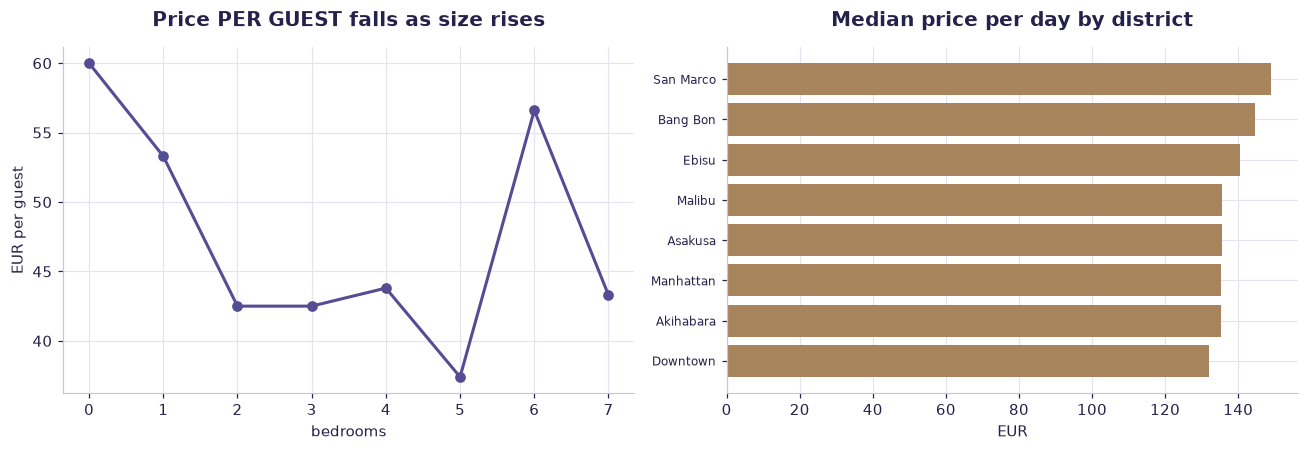

In [6]:
price = "Price per Day EUR"
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
g = df.groupby("#Bedrooms")["PricePerGuest"].median().head(8)
ax[0].plot(g.index, g.values, marker="o", color=ACCENT, lw=2)
ax[0].set_title("Price PER GUEST falls as size rises"); ax[0].set_xlabel("bedrooms"); ax[0].set_ylabel("EUR per guest")

top = df["District"].value_counts().head(8).index
m = df[df["District"].isin(top)].groupby("District")[price].median().sort_values()
ax[1].barh(m.index, m.values, color=BUILDER)
ax[1].set_title("Median price per day by district"); ax[1].set_xlabel("EUR")
ax[1].tick_params(axis="y", labelsize=8)
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Price/guest: mean €57 · median €50 · range €2–€466 (a right-skewed target — model the median, not the mean)
2. Counter-intuitive: price/guest FALLS as bedrooms rise (studio €65 → 3-bed €47) — per-guest economics, not per-listing
3. Instant-booking listings are slightly cheaper (€53 vs €59) — convenience trades against price
4. Review score band 90–100 → €59 vs €50 below — quality commands a modest premium
5. The investor question needs assumptions AI can't supply: occupancy rate, cleaning/turnover cost, regulation (Paris caps short-term lets), and financing


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.


---
*Applied AI Academy · appliedai.center*
